# Load The Whole DTD With PyTorch

This notebook downloads the Describable Textures Dataset (DTD) through `torchvision`, loads the official `train`, `val`, and `test` splits, and concatenates them into one PyTorch dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import ConcatDataset, DataLoader
from torchvision.datasets import DTD
from torchvision.transforms import v2 as transforms


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
transforms = transforms.Compose(
    [transforms.ToTensor()]
)
train_ds = DTD(root=str("/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/data"), split="train", download=True, transform=transforms)
val_ds = DTD(root=str("/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/data"), split="val", download=True, transform=transforms)
test_ds = DTD(root=str("/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/data"), split="test", download=True, transform=transforms)

full_dtd = ConcatDataset([train_ds, val_ds, test_ds])
classes = train_ds.classes

print(f"Train samples: {len(train_ds):,}")
print(f"Validation samples: {len(val_ds):,}")
print(f"Test samples: {len(test_ds):,}")
print(f"All DTD samples: {len(full_dtd):,}")
print(f"Number of classes: {len(classes)}")
print(classes[:10])

Train samples: 1,880
Validation samples: 1,880
Test samples: 1,880
All DTD samples: 5,640
Number of classes: 47
['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline']


Image shape: (494, 500, 3)
Test image shape (C, H, W): torch.Size([3, 494, 500])


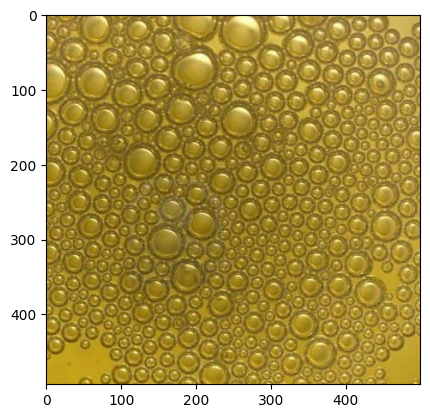

In [23]:
# Load  this image
img_path = "/home/karella/Projects/rotation-invariant-neural-networks/hippy2d/data/dtd/dtd/images/bubbly/bubbly_0056.jpg"
img = plt.imread(img_path)
print(f"Image shape: {img.shape}")
plt.imshow(img)
# Calculate moments in every rgb 
# channel and  
test_img = torch.from_numpy(img).float().permute(2, 0, 1)  # Convert to CxHxW
print(f"Test image shape (C, H, W): {test_img.shape}")

In [ ]:
from escnn import nn
from escnn import gspaces

r2_act = gspaces.rot2dOnR2(N=-1)

feat_type_in = nn.FieldType(r2_act, 3 * [r2_act.irrep(0)])
feat_type_hid = nn.FieldType(
    r2_act,
    3 * [r2_act.irrep(0)] +
    3 * [r2_act.irrep(1)] +
    3 * [r2_act.irrep(2)] +
    3 * [r2_act.irrep(3)] +
    3 * [r2_act.irrep(4)]
)

model = torch.nn.Sequential(
    nn.R2Conv(feat_type_in, feat_type_hid, kernel_size=11),
).eval()

x = feat_type_in(test_img.unsqueeze(0).to(dtype=torch.float32))
out = model(x)

trivials, type1, type2, type3, type4 = out.split([3, 6, 6, 6, 6])


In [44]:
# Split type2 into 6 channels and plot each one
type0_ch = type3.tensor.squeeze(0).detach().cpu().numpy()  # (6, H, W)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
channel_names = [f"Channel {i}" for i in range(3)]

for i in range(3):
    # Top row: feature channels
    im_top = axes[0, i].imshow(type0_ch[i], cmap="coolwarm")
    axes[0, i].set_title(channel_names[i])
    axes[0, i].axis("off")
    plt.colorbar(im_top, ax=axes[0, i], fraction=0.046, pad=0.04)

    # Bottom row: zero masks
    zero_mask = type0_ch[i] < 1e-5
    zero_count = zero_mask.mean()
    im_bottom = axes[1, i].imshow(zero_mask, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Zero mask {i} ({zero_count:.1%})")
    axes[1, i].axis("off")
    plt.colorbar(im_bottom, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

NameError: name 'type3' is not defined